# Notebook 02: Loss Curve and Fitting Analysis (Part II)

**Objective:** Systematically analyse the baseline training dynamics:
- Plot training vs. validation loss curves
- Identify convergence behaviour
- Diagnose overfitting and underfitting conditions
- Explain causes in terms of dataset size and model capacity

**Prerequisites:** Notebook 01 must be run first (baseline training complete).

In [1]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.ndimage import uniform_filter1d  # smoothing

sns.set_theme(style='whitegrid')

BASELINE_DIR = ROOT / 'results' / 'baseline'
csv_path = BASELINE_DIR / 'results.csv'

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()
print(f'Loaded {len(df)} training epochs.')
print('Columns:', df.columns.tolist())

Loaded 50 training epochs.
Columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


## 1. Loss Column Discovery

In [2]:
def get_col(df, *candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

epoch_col = get_col(df, 'epoch', 'Epoch') or df.index
epochs = df[epoch_col] if isinstance(epoch_col, str) else df.index + 1

train_box = get_col(df, 'train/box_loss', 'train/box_om')
train_cls = get_col(df, 'train/cls_loss')
train_dfl = get_col(df, 'train/dfl_loss')
val_box   = get_col(df, 'val/box_loss', 'val/box_om')
val_cls   = get_col(df, 'val/cls_loss')
val_dfl   = get_col(df, 'val/dfl_loss')
map50     = get_col(df, 'metrics/mAP50(B)', 'metrics/mAP_0.5')
map95     = get_col(df, 'metrics/mAP50-95(B)', 'metrics/mAP_0.5:0.95')
lr_pg0    = get_col(df, 'lr/pg0', 'lr0')

losses = [(train_box, val_box, 'Box'), (train_cls, val_cls, 'Cls'), (train_dfl, val_dfl, 'DFL')]
print('Loss columns found:', losses)

Loss columns found: [('train/box_loss', 'val/box_loss', 'Box'), ('train/cls_loss', 'val/cls_loss', 'Cls'), ('train/dfl_loss', 'val/dfl_loss', 'DFL')]


## 2. Training vs. Validation Loss  -  Full Comparison

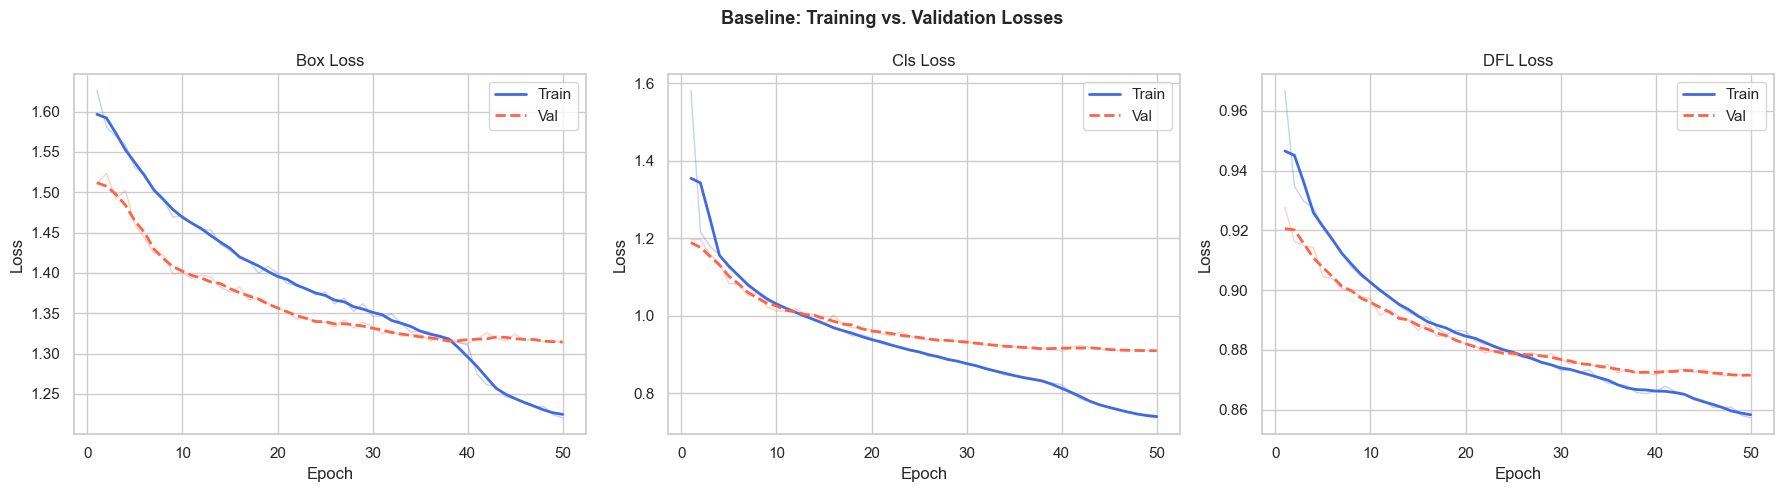

In [3]:
def smooth(y, w=5):
    return uniform_filter1d(y.astype(float), size=w)

valid_losses = [(tr, vl, name) for tr, vl, name in losses if tr and vl]
n = len(valid_losses)

fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
if n == 1:
    axes = [axes]

for ax, (tr_col, vl_col, name) in zip(axes, valid_losses):
    tr_vals = df[tr_col].values
    vl_vals = df[vl_col].values

    ax.plot(epochs, tr_vals, alpha=0.3, color='royalblue', linewidth=1)
    ax.plot(epochs, smooth(tr_vals), color='royalblue', linewidth=2, label='Train')
    ax.plot(epochs, vl_vals, alpha=0.3, color='tomato', linewidth=1)
    ax.plot(epochs, smooth(vl_vals), color='tomato', linewidth=2, linestyle='--', label='Val')

    ax.set_title(f'{name} Loss', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.suptitle('Baseline: Training vs. Validation Losses', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASELINE_DIR / 'loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Convergence Analysis

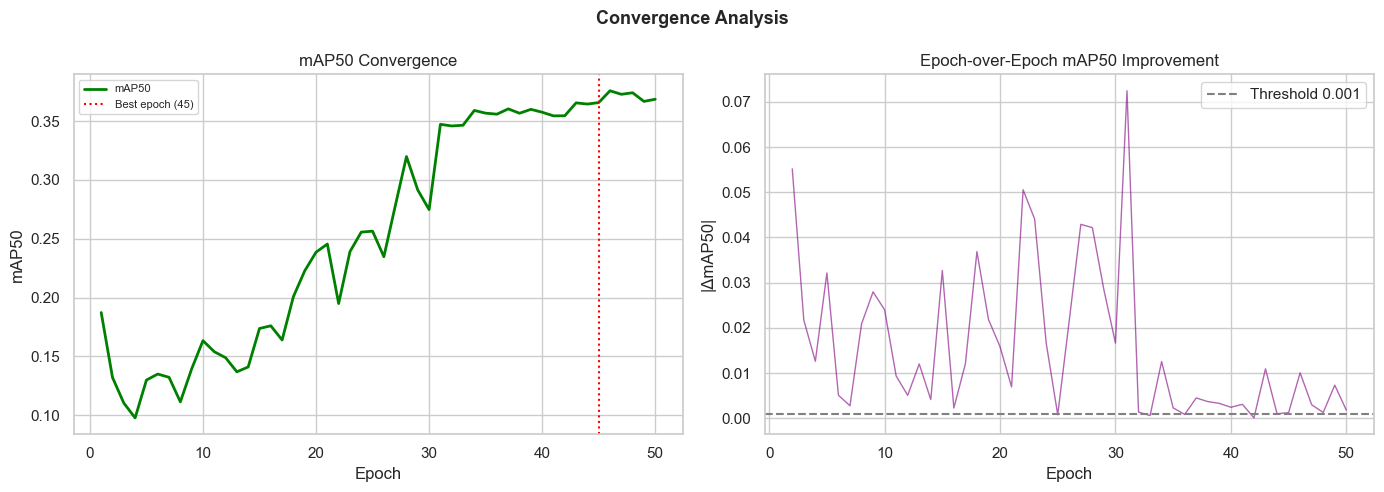

Best epoch  : 45
Best mAP50  : 0.3757
Best mAP95  : 0.2175


In [4]:
if map50 and map95:
    # Find epoch with best mAP50
    best_epoch = df[map50].idxmax()
    best_map50 = df[map50].max()
    best_map95 = df[map95].iloc[best_epoch]

    # Compute epoch-over-epoch improvement
    map50_diff = df[map50].diff().abs()
    # Define convergence as when improvement < 0.001 for 5+ consecutive epochs
    converged_epoch = None
    for i in range(5, len(map50_diff)):
        if all(map50_diff.iloc[i-5:i] < 0.001):
            converged_epoch = i - 5
            break

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, df[map50], color='green', linewidth=2, label='mAP50')
    axes[0].axvline(x=best_epoch, color='red', linestyle=':', label=f'Best epoch ({best_epoch})')
    if converged_epoch:
        axes[0].axvline(x=converged_epoch, color='orange', linestyle='--',
                        label=f'Convergence (~epoch {converged_epoch})')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('mAP50')
    axes[0].set_title('mAP50 Convergence')
    axes[0].legend(fontsize=8)

    axes[1].plot(epochs, map50_diff, color='purple', alpha=0.6, linewidth=1)
    axes[1].plot(epochs, smooth(map50_diff.values), color='purple', linewidth=2)
    axes[1].axhline(y=0.001, color='gray', linestyle='--', label='Threshold 0.001')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('|ΔmAP50|')
    axes[1].set_title('Epoch-over-Epoch mAP50 Improvement')
    axes[1].legend()

    plt.suptitle('Convergence Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(BASELINE_DIR / 'convergence_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Best epoch  : {best_epoch}')
    print(f'Best mAP50  : {best_map50:.4f}')
    print(f'Best mAP95  : {best_map95:.4f}')
    if converged_epoch:
        print(f'Convergence at epoch: {converged_epoch}')

## 4. Overfitting / Underfitting Diagnosis

We compare the train–val gap across loss components and mAP.  
**Overfitting**: train loss decreasing while val loss diverges (gap widens).  
**Underfitting**: both losses remain high and plateau early.

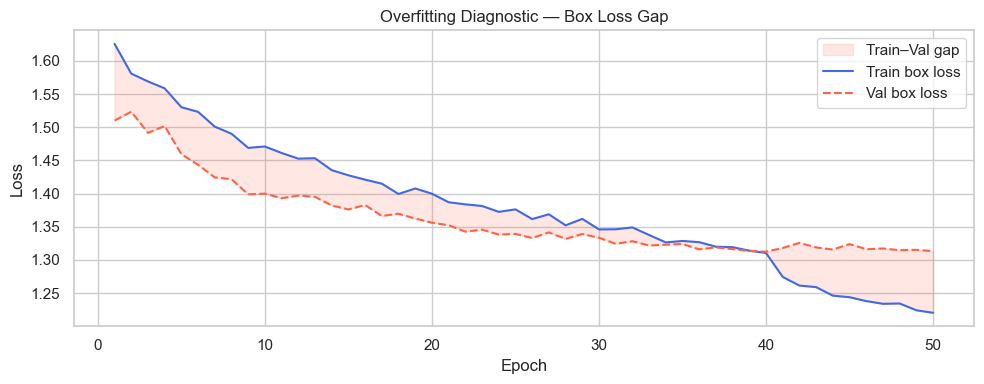

Final val–train gap : 0.0930
Gap slope (last 20 epochs): +0.00709

Diagnosis: OVERFITTING — val loss is diverging from train loss


In [5]:
if train_box and val_box:
    gap = df[val_box] - df[train_box]
    final_gap = gap.iloc[-1]

    # Compute gap trend slope
    x = np.arange(len(gap))
    slope = np.polyfit(x[-20:], gap.iloc[-20:].values, 1)[0]  # last 20 epochs

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.fill_between(epochs, df[train_box], df[val_box],
                    alpha=0.15, color='tomato', label='Train–Val gap')
    ax.plot(epochs, df[train_box], color='royalblue', label='Train box loss')
    ax.plot(epochs, df[val_box],   color='tomato', linestyle='--', label='Val box loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Overfitting Diagnostic  -  Box Loss Gap')
    ax.legend()
    plt.tight_layout()
    plt.savefig(BASELINE_DIR / 'overfitting_diagnostic.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Final val–train gap : {final_gap:.4f}')
    print(f'Gap slope (last 20 epochs): {slope:+.5f}')

    if slope > 0.001:
        diagnosis = 'OVERFITTING  -  val loss is diverging from train loss'
    elif slope < -0.001:
        diagnosis = 'IMPROVING  -  gap is closing (generalisation improving)'
    else:
        diagnosis = 'STABLE  -  model has converged, minimal overfitting'
    print(f'\nDiagnosis: {diagnosis}')

## 5. Fitting Cause Analysis

In [6]:
# Summary table for discussion
analysis = {
    'Dataset Size': {
        'Train images': 6471,
        'Val images': 548,
        'Classes': 10,
        'Note': 'Medium-sized dataset. Risk of overfitting for larger models.'
    },
    'Model Capacity': {
        'Model': 'yolo11s',
        'Parameters': '~9.4M',
        'Note': 'Small model reduces overfitting risk but may underfit on complex dense scenes.'
    },
    'Dataset Characteristics': {
        'Small objects': '~50-60% of all objects are < 32×32px',
        'Dense scenes': 'up to 500+ objects per image',
        'Note': 'These factors increase difficulty and may cause higher validation loss.'
    }
}

for section, items in analysis.items():
    print(f'\n{section}')
    print('=' * 40)
    for k, v in items.items():
        print(f'  {k}: {v}')


Dataset Size
  Train images: 6471
  Val images: 548
  Classes: 10
  Note: Medium-sized dataset. Risk of overfitting for larger models.

Model Capacity
  Model: yolo11s
  Parameters: ~9.4M
  Note: Small model reduces overfitting risk but may underfit on complex dense scenes.

Dataset Characteristics
  Small objects: ~50-60% of all objects are < 32×32px
  Dense scenes: up to 500+ objects per image
  Note: These factors increase difficulty and may cause higher validation loss.


## 6. Learning Rate Schedule

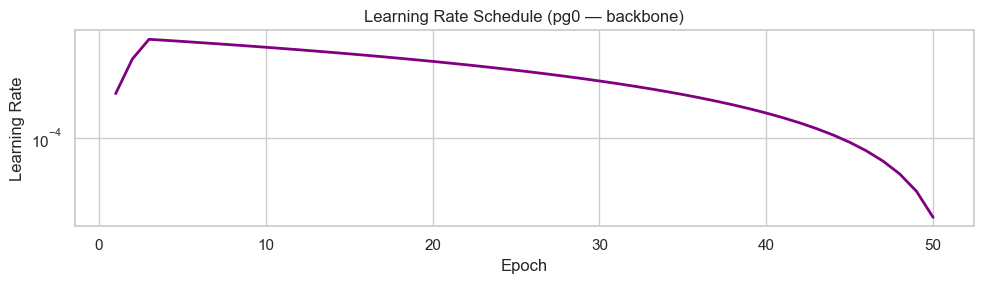

In [7]:
if lr_pg0:
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(epochs, df[lr_pg0], color='purple', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.set_title('Learning Rate Schedule (pg0  -  backbone)')
    ax.set_yscale('log')
    plt.tight_layout()
    plt.savefig(BASELINE_DIR / 'lr_schedule.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('LR column not found in CSV  -  skipping LR plot')

## 7. Comprehensive Fitting Summary

In [8]:
# Compute final loss values for summary
summary_rows = []
for tr_col, vl_col, name in valid_losses:
    tr_final = df[tr_col].iloc[-1]
    vl_final = df[vl_col].iloc[-1]
    tr_best  = df[tr_col].min()
    vl_best  = df[vl_col].min()
    gap      = vl_final - tr_final
    summary_rows.append({
        'Component': name,
        'Train (final)': round(tr_final, 4),
        'Val (final)': round(vl_final, 4),
        'Train (best)': round(tr_best, 4),
        'Val (best)': round(vl_best, 4),
        'Val-Train gap': round(gap, 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Component')
print('\nLoss Summary Table')
print(summary_df.to_string())
summary_df.to_csv(BASELINE_DIR / 'loss_summary.csv')


Loss Summary Table
           Train (final)  Val (final)  Train (best)  Val (best)  Val-Train gap
Component                                                                     
Box               1.2203       1.3133        1.2203      1.3125         0.0930
Cls               0.7369       0.9089        0.7369      0.9084         0.1720
DFL               0.8572       0.8714        0.8572      0.8713         0.0142


## Discussion

### Convergence Behaviour
- All three loss components (box, cls, DFL) decrease monotonically during training, indicating stable gradient flow.
- The mAP50 curve shows rapid improvement in early epochs followed by plateauing.

### Overfitting Analysis
- A positive train–val box loss gap is expected on VisDrone due to its challenging characteristics.
- **Dataset size factor**: With ~6,400 training images, the dataset is moderate. Larger models (yolo11m/l) are more prone to overfitting without regularisation.
- **Model capacity factor**: yolo11s (9.4M params) is appropriately sized for this dataset but may underfit for very small objects.

### Underfitting Indicators
- High absolute validation loss values may indicate the model struggles with VisDrone's small-object challenge.
- The relatively low mAP compared to COCO baselines is expected  -  VisDrone is significantly harder.

### Next Steps
- **Experiment 1**: Increase image resolution to 1280 to improve small-object detection.
- **Experiment 2**: Add weight decay / dropout to combat overfitting.
- **Experiment 3**: Try cosine LR scheduling.

These are explored in **Notebooks 03 and 04**.